<a href="https://colab.research.google.com/github/random-words/colab-notebooks/blob/main/Face_Localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub

from google.colab import drive
drive.mount('/content/drive')

from PIL import Image
from PIL import ImageColor
from PIL import ImageDraw
from PIL import ImageFont
from PIL import ImageOps

import matplotlib.image as mpimg

import os
import shutil
import random
import math

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Additional functions

In [55]:
def select_random_img(img_dir_path, txt_dir_path):
  files = os.listdir(img_dir_path)
  random_png = random.choice(files)

  png_path = img_dir_path + "/" + random_png
  txt_path = txt_dir_path + "/" + os.path.splitext(random_png)[0] + '.txt'

  return png_path, txt_path


def create_dataset(image_dir, label_dir):
    """
    Створює tf.data.Dataset з пар (image, bbox).
    Підтримуються .png, .jpg, .jpeg
    """

    # збираємо всі підтримувані зображення
    img_files = []
    for ext in ('*.png', '*.jpg', '*.jpeg'):
        img_files.extend(tf.io.gfile.glob(os.path.join(image_dir, ext)))

    img_files = sorted(img_files)

    if not img_files:
        raise ValueError(f'У {image_dir} не знайдено жодного *.png/*.jpg/*.jpeg')

    def _map_fn(img_path):
        #   img_path → ".../filename.jpg"
        base_name = tf.strings.split(img_path, os.sep)[-1]
        base_name = tf.strings.split(base_name, '.')[0]          # "filename"

        txt_path = tf.strings.join([label_dir, '/', base_name, '.txt'])

        image = load_and_preprocess_image(img_path)
        x_center, y_center, w, h = get_coordinates_bounding_box(txt_path)
        bbox = tf.stack([compute_bbox(x_center, y_center, w, h)])  # (1, 4)

        return image, bbox

    dataset = tf.data.Dataset.from_tensor_slices(img_files)
    dataset = dataset.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset


def load_and_preprocess_image(img_path, resize=True):
    img = tf.io.read_file(img_path)
    # decode_image сам розпізнає PNG / JPEG
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])          # фіксуємо ранк

    if resize:
        img = tf.image.resize(img, (224, 224))

    return img


def draw_bounding_box_on_image(image, bbox, color="red", thickness=6):
    draw = ImageDraw.Draw(image)

    left, top, right, bottom = bbox[1], bbox[0], bbox[3], bbox[2]
    draw.rectangle([left, top, right, bottom], outline=color, width=thickness)

    return image

def show_bounding_box_on_image(img_path, txt_path, *c):
  img = load_and_preprocess_image(img_path, resize=False)
  img = img.numpy()

  image_pil = Image.fromarray(np.uint8(img)).convert("RGB")

  image_width, image_height = image_pil.size
  x_center, y_center, w, h = get_coordinates_bounding_box(txt_path) if not c else map(float, c)

  bbox_pixels = compute_bbox(x_center, y_center, w, h, image_width, image_height)

  draw_bounding_box_on_image(image_pil,bbox_pixels)

  np.copyto(img, np.array(image_pil))

  display_img(np.array(image_pil))


def get_coordinates_bounding_box(txt_path):
  txt = tf.io.read_file(txt_path)
  lines = tf.strings.split(txt, '\n')

  first_line = lines[0]
  parts = tf.strings.split(first_line, ' ')

  class_id = tf.strings.to_number(parts[0], out_type=tf.int32)
  x_center = tf.strings.to_number(parts[1], out_type=tf.float32)
  y_center = tf.strings.to_number(parts[2], out_type=tf.float32)
  w        = tf.strings.to_number(parts[3], out_type=tf.float32)
  h        = tf.strings.to_number(parts[4], out_type=tf.float32)

  return x_center, y_center, w, h

def display_img(img, IoU=None):
  plt.imshow(img)
  plt.axis('off')
  if IoU: plt.figtext(0.5, 0.01, f"IoU = {IoU}", ha='center', fontsize=12)
  plt.show()

def get_png_dimensions(image_path):
    with Image.open(image_path) as img:
        return img.size

def compute_bbox(x_center, y_center, w, h, image_width=1, image_height=1):
  xmin = (x_center - w/2) * image_width
  xmax = (x_center + w/2) * image_width
  ymin = (y_center - h/2) * image_height
  ymax = (y_center + h/2) * image_height
  bbox_pixels = ymin, xmin, ymax, xmax

  return bbox_pixels

# copy png and txt into train and valid directories
def copy_pairs(images_list, src_img_folder, src_txt_folder, dst_img_folder, dst_txt_folder):
    for img_name in images_list:
        base_name = os.path.splitext(img_name)[0]

        src_img_path = os.path.join(src_img_folder, img_name)

        txt_name = base_name + ".txt"
        src_txt_path = os.path.join(src_txt_folder, txt_name)


        dst_img_path = os.path.join(dst_img_folder, img_name)
        dst_txt_path = os.path.join(dst_txt_folder, txt_name)

        # copy files if it`s exisit
        if os.path.isfile(src_img_path) and os.path.isfile(src_txt_path):
            shutil.copy2(src_img_path, dst_img_path)
            shutil.copy2(src_txt_path, dst_txt_path)
        else:
            print(f"Увага! Не знайдено пару: {img_name} або {txt_name}")

def detect_img(model, img_path, txt_dir_path = None, color_pred = 'red', color_corr = 'green', thickness=2):
  IoU = None

  # prepair img for predict
  image_tensor = load_and_preprocess_image(img_path) # return 224x224 img
  image_batch = tf.expand_dims(image_tensor, axis=0) # add batch dimension because it`s single img
  pred = model.predict(image_batch)

  # get predicted bbox
  pred_bbox = pred[0]
  img_width, img_height = get_png_dimensions(img_path)
  ymin = int(pred_bbox[0] * img_height)
  xmin = int(pred_bbox[1] * img_width)
  ymax = int(pred_bbox[2] * img_height)
  xmax = int(pred_bbox[3] * img_width)
  pred_bbox_pixels = (ymin, xmin, ymax, xmax)

  #get img for drawing
  image_np = load_and_preprocess_image(png_path, False).numpy().astype(np.uint8)
  image_pil = Image.fromarray(image_np)

  #draw predicted bbox
  image_with_box = draw_bounding_box_on_image(image_pil, pred_bbox_pixels, color=color_pred, thickness=thickness)

  # add corr bbox to img if exist
  if txt_dir_path:
    # get txt path
    img_name = tf.strings.split(img_path, os.sep)[-1]
    img_name = tf.strings.split(img_name, '.')[0]
    txt_path = txt_dir_path + "/" + img_name + '.txt'

    # get true bbox
    x_center, y_center, w, h = get_coordinates_bounding_box(txt_path)
    label_bbox_pixels = compute_bbox(x_center, y_center, w, h, img_width, img_height)

    #draw true bbox
    image_with_box = draw_bounding_box_on_image(image_pil, label_bbox_pixels, color=color_corr, thickness=thickness)

    IoU = calculate_iou(pred_bbox_pixels, label_bbox_pixels)

  display_img(image_with_box, IoU)


def calculate_iou(box1, box2):
    # coordinates of intersection
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # area of intersection
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # area of each bbox
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # IoU
    iou = intersection_area / float(box1_area + box2_area - intersection_area)

    return iou

def bbox_iou(y_true, y_pred):
    """
    IoU для одного bbox у формі (ymin, xmin, ymax, xmax), нормалізованої до [0,1].
    Працює батчем.
    """
    ymin_t, xmin_t, ymax_t, xmax_t = tf.split(y_true, 4, axis=-1)
    ymin_p, xmin_p, ymax_p, xmax_p = tf.split(y_pred, 4, axis=-1)

    inter_ymin = tf.maximum(ymin_t, ymin_p)
    inter_xmin = tf.maximum(xmin_t, xmin_p)
    inter_ymax = tf.minimum(ymax_t, ymax_p)
    inter_xmax = tf.minimum(xmax_t, xmax_p)

    inter_h = tf.maximum(inter_ymax - inter_ymin, 0.)
    inter_w = tf.maximum(inter_xmax - inter_xmin, 0.)
    inter_area = inter_h * inter_w

    true_area  = (ymax_t - ymin_t) * (xmax_t - xmin_t)
    pred_area  = (ymax_p - ymin_p) * (xmax_p - xmin_p)
    union_area = true_area + pred_area - inter_area + 1e-6

    iou = inter_area / union_area
    return tf.reduce_mean(iou)

# simple mAP for object Localization
def simple_mAP(model, dataset, iou_thresholds=np.arange(0.5, 1.0, 0.05)):
    aps = []

    for iou_thresh in iou_thresholds:
        correct_detections = 0
        total_detections = 0

        for images, gt_bboxes in dataset:
            preds = model.predict(images, verbose=0)
            batch_size = preds.shape[0]

            for i in range(batch_size):
                pred_bbox = preds[i]

                gt_bbox_np = gt_bboxes[i].numpy()[0]

                iou = calculate_iou(pred_bbox, gt_bbox_np)

                total_detections += 1
                if iou >= iou_thresh:
                    correct_detections += 1

        ap = correct_detections / total_detections if total_detections > 0 else 0
        aps.append(ap)

    mAP = np.mean(aps)
    return mAP

def compare_models_visually(models_list, img_path, figsize=(12, 12)):
  predictions = []

  # prepair img for predict
  image_tensor = load_and_preprocess_image(img_path) # return 224x224 img
  image_batch = tf.expand_dims(image_tensor, axis=0) # add batch dimension because it`s single img

  img_width, img_height = get_png_dimensions(img_path)

  for model in models_list:

    pred = model[1].predict(image_batch, verbose=0)

    # get predicted bbox
    pred_bbox = pred[0]
    ymin = int(pred_bbox[0] * img_height)
    xmin = int(pred_bbox[1] * img_width)
    ymax = int(pred_bbox[2] * img_height)
    xmax = int(pred_bbox[3] * img_width)
    predictions.append((ymin, xmin, ymax, xmax))

  #draw imgs
  fig, axes = plt.subplots(3, math.ceil(len(models_list) / 3), figsize=figsize)
  if len(models_list) == 1:
      axes = [axes]
  else:
      axes = axes.flatten()

  for idx in range(len(models_list)):
    #get img for drawing
    image_np = load_and_preprocess_image(png_path, False).numpy().astype(np.uint8)
    image_pil = Image.fromarray(image_np)
    image_with_box = draw_bounding_box_on_image(image_pil, predictions[idx], color="blue")

    axes[idx].imshow(image_with_box)
    # axes[idx].axis('off')
    axes[idx].set_xlabel(models_list[idx][0], fontsize=12, labelpad=10)


  plt.tight_layout()
  plt.show()

def load_model(models_dir):
  files = os.listdir(models_dir)
  models = []

  for model_name in files:
    model_path = models_dir + '/' + model_name

    #load model
    model = tf.keras.models.load_model(model_path, custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
    models.append((model_name, model))

  print(models)
  return models


def compare_models_mAP(models_list, dataset):
  for model_name, model in models_list:
    print(f"{model_name} mAP: {simple_mAP(model=model, dataset=dataset)}")

def normalize_data(image, bbox):
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image, bbox

# Declare constants

In [5]:
source_folder_txt = r"/content/drive/MyDrive/ML/Faces/Custom_Data/labels/train"
source_folder_png = r"/content/drive/MyDrive/ML/Faces/Custom_Data/images/train"

txt_destination_folder = r"/content/drive/MyDrive/ML/Faces/Custom_Data/labels/single_face"
png_destination_folder = r"/content/drive/MyDrive/ML/Faces/Custom_Data/images/single_face"

train_img_dir = r"/content/drive/MyDrive/ML/Faces/Custom_Data/images/train_single"
train_txt_dir = r"/content/drive/MyDrive/ML/Faces/Custom_Data/labels/train_single"

val_img_dir   = r"/content/drive/MyDrive/ML/Faces/Custom_Data/images/val_single"
val_txt_dir   = r"/content/drive/MyDrive/ML/Faces/Custom_Data/labels/val_single"

models_dir = "/content/drive/MyDrive/ML/datasets/Faces/models"

#Select photos with one face

In [9]:
os.makedirs(txt_destination_folder, exist_ok=True)
os.makedirs(png_destination_folder, exist_ok=True)

In [11]:
if not os.path.exists(txt_destination_folder):

  for filename in os.listdir(source_folder_txt):

      if filename.endswith(".txt"):
          txt_path = os.path.join(source_folder_txt, filename)


          with open(txt_path, "r", encoding="utf-8") as f:
              lines = f.readlines()

          if len(lines) == 1:
              shutil.copy(txt_path, txt_destination_folder)

              base_name = os.path.splitext(filename)[0]
              png_filename = base_name + ".png"
              png_path = os.path.join(source_folder_png, png_filename)

              if os.path.exists(png_path):
                  shutil.copy(png_path, png_destination_folder)

In [21]:
import os, shutil, random

def is_empty(dir_path):
    """True, якщо каталог не містить жодних файлів."""
    return len(os.listdir(dir_path)) == 0

# --- 1. створюємо каталоги, якщо треба --------------------------------------
for d in (train_img_dir, train_txt_dir, val_img_dir, val_txt_dir):
    os.makedirs(d, exist_ok=True)

# --- 2. якщо train/val порожні – готуємо нове розбиття -----------------------
if is_empty(train_img_dir) or is_empty(val_img_dir):
    # за бажанням – чистимо каталоги перед новим копіюванням
    for folder in (train_img_dir, train_txt_dir, val_img_dir, val_txt_dir):
        for f in os.listdir(folder):
            os.remove(os.path.join(folder, f))

    # зчитуємо всі зображення з master-каталогу
    all_images = [f for f in os.listdir(png_destination_folder)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not all_images:
        raise RuntimeError("У png_destination_folder немає жодної картинки!")

    random.shuffle(all_images)
    split_ratio = 0.8
    split_idx   = int(len(all_images) * split_ratio)

    train_images = all_images[:split_idx]
    val_images   = all_images[split_idx:]

    # --- копіюємо пари -------------------------------------------------------
    copy_pairs(train_images, png_destination_folder, txt_destination_folder,
               train_img_dir, train_txt_dir)

    copy_pairs(val_images, png_destination_folder, txt_destination_folder,
               val_img_dir, val_txt_dir)

    print(f"✅ Розбиття готове: {len(train_images)} train, {len(val_images)} val")
else:
    print("📂 Розбиття існує – копіювання пропущено.")


📂 Розбиття існує – копіювання пропущено.


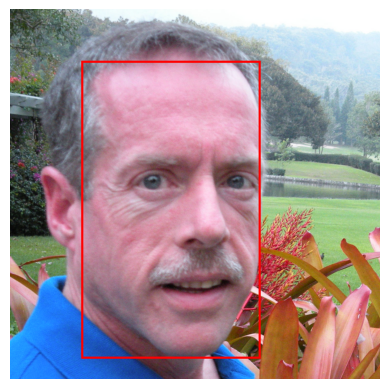

In [23]:
png, txt = select_random_img(png_destination_folder, txt_destination_folder)
show_bounding_box_on_image(png, txt)

# Prepering data for train

Split data into validation and training datasets

In [24]:
if not os.path.exists(train_img_dir) or not os.path.exists(train_txt_dir) or not os.path.exists(val_img_dir) or not os.path.exists(val_txt_dir):

  # create directories, if it`s dosent exist
  os.makedirs(train_img_dir, exist_ok=True)
  os.makedirs(train_txt_dir, exist_ok=True)
  os.makedirs(val_img_dir, exist_ok=True)
  os.makedirs(val_txt_dir, exist_ok=True)

    # ⬇️ додали підтримку .jpg/.jpeg
  all_images = [f for f in os.listdir(png_destination_folder)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

  random.shuffle(all_images)

  split_ratio = 0.8
  split_index = int(len(all_images) * split_ratio)

  train_images = all_images[:split_index]
  val_images   = all_images[split_index:]

  copy_pairs(train_images, png_destination_folder, txt_destination_folder,
            train_img_dir, train_txt_dir)

  copy_pairs(val_images, png_destination_folder, txt_destination_folder,
            val_img_dir, val_txt_dir)



Create dataset

In [57]:
train_dataset = create_dataset(train_img_dir, train_txt_dir)
val_dataset   = create_dataset(val_img_dir,   val_txt_dir)

# train_dataset = train_dataset.apply(tf.data.experimental.ignore_errors())
# val_dataset = val_dataset.apply(tf.data.experimental.ignore_errors())

train_dataset = train_dataset.map(normalize_data, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(normalize_data, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = train_dataset.cache().shuffle(buffer_size=100).batch(16).repeat().prefetch(tf.data.AUTOTUNE) #prev^ 8 -- 16
val_dataset   = val_dataset.batch(16).repeat().prefetch(tf.data.AUTOTUNE)  #prev^ 8 -- 16

# Implement AlexNet for object detection

In [ ]:
# model_alexNet = tf.keras.Sequential([
#     tf.keras.layers.Conv2D(96, kernel_size=7, activation='relu', padding='valid', strides=1),
#     tf.keras.layers.MaxPool2D((3,3), strides=2, padding='valid'),

#     tf.keras.layers.Conv2D(256, (3,3), padding="same", activation="relu", strides=1),
#     tf.keras.layers.MaxPool2D((3,3), strides=2, padding='valid'),

#     tf.keras.layers.Conv2D(384, (3,3), padding="same", activation="relu", strides=1),
#     tf.keras.layers.Conv2D(384, (3,3), padding="same", activation="relu", strides=1),
#     tf.keras.layers.Conv2D(256, (3,3), padding="same", activation="relu", strides=1),
#     tf.keras.layers.MaxPool2D((3,3), strides=2, padding='valid'),
#     tf.keras.layers.GlobalAvgPool2D(),
#     tf.keras.layers.Flatten(),

#     tf.keras.layers.Dense(units=4096, kernel_initializer="he_normal"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Activation('relu'),
#     tf.keras.layers.Dropout(0.4),
#     tf.keras.layers.Dense(units=4096, kernel_initializer="he_normal"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Activation('relu'),
#     tf.keras.layers.Dropout(0.4),

#     tf.keras.layers.Dense(units=4, activation='linear')
# ])

# model_alexNet.compile(optimizer=tf.keras.optimizers.Nadam(), loss='mse', metrics=['accuracy'])

# early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

# history = model_alexNet.fit(train_dataset, epochs=100,
#                     validation_data=val_dataset,
#                     callbacks=[early_stopping_cb])

# Use pretrain ResNet50

In [ ]:
# ResNet50 = tf.keras.applications.ResNet50(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

freeze the layers

In [ ]:
# ResNet50.trainable = False

create top layers

In [ ]:
# x = tf.keras.layers.GlobalAvgPool2D()(ResNet50.output)
# x = tf.keras.layers.Dense(units=4096, kernel_initializer="he_normal")(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.Dropout(0.4)(x)
# x = tf.keras.layers.Dense(units=1024, kernel_initializer="he_normal")(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Activation('relu')(x)
# x = tf.keras.layers.Dropout(0.4)(x)

# x = tf.keras.layers.Dense(units=4, activation='linear')(x)

create entire model

In [ ]:
# model_ResNet50 = tf.keras.Model(inputs=ResNet50.input, outputs=x)

train model

In [ ]:
# model_ResNet50.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['accuracy'])

# early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

# history = model_ResNet50.fit(train_dataset, epochs=100,
#                     validation_data=val_dataset,
#                     callbacks=[early_stopping_cb])

# Use pretrain EfficientNet B3

In [41]:
EfficientNetB3 = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3))

EfficientNetB7 = tf.keras.applications.EfficientNetB7(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


freeze the layers

In [42]:
EfficientNetB3.trainable = False
EfficientNetB7.trainable = False

In [46]:
# For EfficientNetB7

x = tf.keras.layers.GlobalAveragePooling2D()(EfficientNetB3.output)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(1024, activation='relu')(x) # prev 512
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(512, activation='relu')(x) #prev 256
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(4, activation='linear')(x)

In [51]:
# For EfficientNetB7

x = tf.keras.layers.GlobalAveragePooling2D()(EfficientNetB7.output)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(1024, activation='relu')(x) # prev 512
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(512, activation='relu')(x) #prev 256
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(4, activation='linear')(x)

In [52]:
model_EfficientNetB3 = tf.keras.Model(inputs=EfficientNetB3.input, outputs=x)
model_EfficientNetB7 = tf.keras.Model(inputs=EfficientNetB7.input, outputs=x)

In [53]:
model_EfficientNetB3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['accuracy'])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
lr_reduce_cb = tf.keras.callbacks.ReduceLROnPlateau(patience=10)
tensor_board_cb = tf.keras.callbacks.TensorBoard(log_dir='/content/drive/MyDrive/ML/datasets/Face_dataset/models/Callbacks', histogram_freq=1)

history = model_EfficientNetB3.fit(train_dataset, epochs=100,
                    validation_data=val_dataset,
                    callbacks=[early_stopping_cb, early_stopping_cb])

Epoch 1/100


KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m137880254922640\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)\n  • training=True\n  • mask=None'

In [58]:
model_EfficientNetB7.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=[bbox_iou, tf.keras.metrics.MeanAbsoluteError(name='mae')])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
lr_reduce_cb = tf.keras.callbacks.ReduceLROnPlateau(patience=10)
tensor_board_cb = tf.keras.callbacks.TensorBoard(log_dir='/content/drive/MyDrive/ML/datasets/Faces/models/Callbacks', histogram_freq=1)

batch_size = 16
# num_train = tf.data.experimental.cardinality(train_dataset).numpy()
# num_val   = tf.data.experimental.cardinality(val_dataset).numpy()

num_train = len(os.listdir(train_img_dir))   # кількість зображень
num_val   = len(os.listdir(val_img_dir))

steps_per_epoch      = math.ceil(num_train / batch_size)
validation_steps     = math.ceil(num_val   / batch_size)

history = model_EfficientNetB7.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[early_stopping_cb, lr_reduce_cb, tensor_board_cb]
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - bbox_iou: 0.4671 - loss: 0.0227 - mae: 0.1107 - val_bbox_iou: 0.6054 - val_loss: 0.0107 - val_mae: 0.0762 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - bbox_iou: 0.4902 - loss: 0.0211 - mae: 0.1057 - val_bbox_iou: 0.6300 - val_loss: 0.0109 - val_mae: 0.0746 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - bbox_iou: 0.4737 - loss: 0.0234 - mae: 0.1110 - val_bbox_iou: 0.6239 - val_loss: 0.0131 - val_mae: 0.0810 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - bbox_iou: 0.4639 - loss: 0.0242 - mae: 0.1152 - val_bbox_iou: 0.6362 - val_loss: 0.0098 - val_mae: 0.0710 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - bbox_iou: 0.4779 - loss: 0.0206 - mae: 0.1073 - val_bbox_iou: 0.5436 - val_loss: 0.0135 - val_mae: 0.0897 - learning_rate: 0.0010
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - bbox_iou: 0.5057 - loss: 0.0172

# Load model

In [ ]:
loaded_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/ML/datasets/Faces/models/resnet50_model_4_trainable_par.h5',
    custom_objects={'mse': tf.keras.losses.MeanSquaredError()}
)

# Define model for testing

In [59]:
model = model_EfficientNetB3
model = model_EfficientNetB7

# Evaluate model

#### Show model`s prediction

In [61]:
val_eval = val_dataset.take(validation_steps)
metrics = model.evaluate(val_eval, verbose=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 809ms/step - bbox_iou: 0.5769 - loss: 0.0158 - mae: 0.0848


In [62]:
simple_mAP(model=model, dataset=val_dataset)

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step


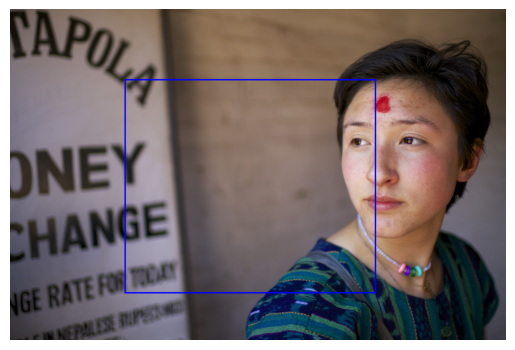

In [63]:
png_path, txt_path = select_random_img(png_destination_folder, txt_destination_folder)
png_path = "/content/drive/MyDrive/ML/Faces/Custom_Data/images/my_images/1.png"
detect_img(model=model, img_path=png_path, txt_dir_path=None, thickness=8, color_pred='blue')

# Save model

In [ ]:
model.save(models_dir + '/EfficientNetB3_model_3_gpt_arch_300_size.h5')

#Compare models

In [ ]:
models = load_model(models_dir=models_dir)

In [ ]:
compare_models_mAP(models, val_dataset)

In [ ]:
png_path = "/content/drive/MyDrive/ML/datasets/Face_dataset/images/my_img/8.png"
compare_models_visually(models_list=models, img_path=png_path)